# 📊 Customer Churn Risk & VIP Analysis (SQL + Python)

## End-to-End Data Science Project

This project identifies high-value customers at risk of churn using SQL, Python, and machine learning.

## 🎯 Business Problem

The goal is to identify high-value customers who are at risk of churning so that the business can take early retention action.

We focus on:
- Revenue at risk
- Customer activity (recency)
- Purchase behavior (frequency & monetary value)
- Predictive churn scoring

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

## 📂 Data Source

Data was extracted from a SQLite database containing:
- transactions
- churn_risk

Filtered view: `high_value_churn_risk`

Exported to CSV and analyzed in Python (pandas).

## 📥 Load Data into Python

In [2]:
df = pd.read_csv("high_value_churn_risk.csv", sep="\t")
df.head()

,CustomerID,frequency,monetary,last_purchase,customer_segment
0,12409.0,7,11056.93,2011-09-22 10:38:00,High Value
1,15749.0,4,21535.90,2011-04-18 13:20:00,High Value
2,16180.0,10,10217.48,2011-08-31 16:28:00,High Value


In [3]:
df.shape

(3, 5)

## 🧹 Data Preparation & Feature Engineering

We convert and create key features for churn analysis:
- last_purchase → datetime
- days_since_purchase → recency metric
- risk_score → weighted churn risk indicator
- churn label → target variable for modeling

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        3 non-null      float64
 1   frequency         3 non-null      int64  
 2   monetary          3 non-null      float64
 3   last_purchase     3 non-null      object 
 4   customer_segment  3 non-null      object 
dtypes: float64(2), int64(1), object(2)
memory usage: 252.0+ bytes


In [5]:
df['last_purchase'] = pd.to_datetime(df['last_purchase'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        3 non-null      float64       
 1   frequency         3 non-null      int64         
 2   monetary          3 non-null      float64       
 3   last_purchase     3 non-null      datetime64[ns]
 4   customer_segment  3 non-null      object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 252.0+ bytes


In [7]:
today = pd.to_datetime("2011-12-01")
df['days_since_purchase'] = (today - df['last_purchase']).dt.days

print("\nDays since last purchase:")
print(df[['CustomerID','days_since_purchase']])


Days since last purchase:
   CustomerID  days_since_purchase
0     12409.0                   69
1     15749.0                  226
2     16180.0                   91


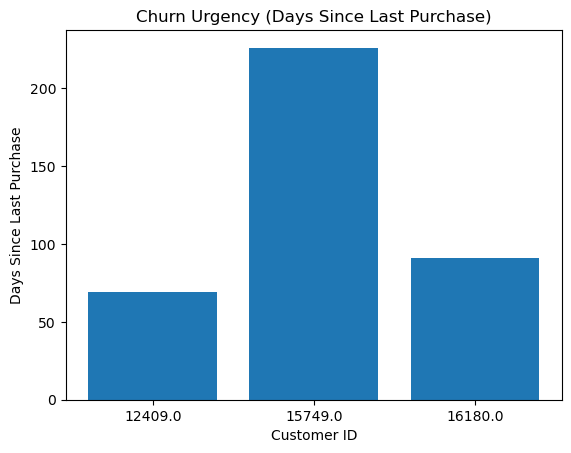

In [8]:
plt.figure()
plt.bar(range(len(df)), df["days_since_purchase"])
plt.xticks(range(len(df)), df["CustomerID"])
plt.xlabel("Customer ID")
plt.ylabel("Days Since Last Purchase")
plt.title("Churn Urgency (Days Since Last Purchase)")
plt.show()

## 💰 Revenue at Risk

In [9]:
# Total monetary value at risk
total_at_risk = df['monetary'].sum()
print("Total revenue at risk: $", total_at_risk)

# Average frequency
avg_frequency = df['frequency'].mean()
print("Average purchase frequency of at-risk VIPs:", avg_frequency)

# Most recent purchase date
latest_purchase = df['last_purchase'].max()
print("Most recent purchase among at-risk VIPs:", latest_purchase)

Total revenue at risk: $ 42810.31
Average purchase frequency of at-risk VIPs: 7.0
Most recent purchase among at-risk VIPs: 2011-09-22 10:38:00


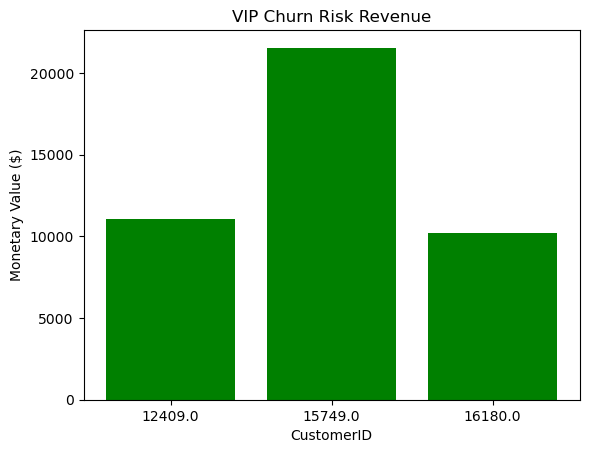

In [10]:
# Bar chart
plt.figure()
plt.bar(range(len(df)), df['monetary'], color="green")
plt.xticks(range(len(df)), df['CustomerID'])
plt.xlabel('CustomerID')
plt.ylabel('Monetary Value ($)')
plt.title('VIP Churn Risk Revenue')
plt.show()

## 🏆 VIP Customer Ranking

In [11]:
# Weighted Importance: Monetary value matters 50%, Frequency matters 20%, Recency (days since purchase) matters 30% 

df['risk_score'] = (
    df['monetary'] * 0.5 +
    df['frequency'] * 0.2 +
    df['days_since_purchase'] * 0.3
)

df_risk = df.sort_values(by='risk_score', ascending=False)

print("\nVIP Risk Ranking:")
print(df_risk[['CustomerID','risk_score']])


VIP Risk Ranking:
   CustomerID  risk_score
1     15749.0   10836.550
0     12409.0    5550.565
2     16180.0    5138.040


## 📊 Data Visualization

## ⚖️ Customer Risk Scoring Model

We create a weighted score to estimate churn risk:

- Monetary value (50%)
- Frequency (20%)
- Recency (30%)

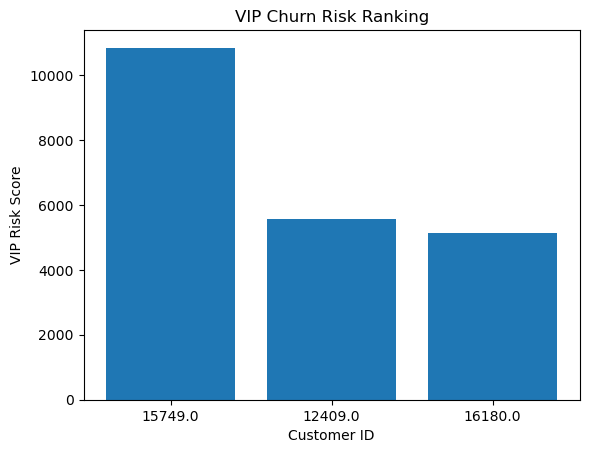

In [12]:
plt.figure()

plt.bar(range(len(df_risk)), df_risk["risk_score"])

plt.xticks(range(len(df_risk)), df_risk["CustomerID"])

plt.xlabel("Customer ID")
plt.ylabel("VIP Risk Score")
plt.title("VIP Churn Risk Ranking")

plt.show()

In [13]:
print("\n--- FINAL BUSINESS INSIGHTS ---")
print("Highest risk VIP:", df_risk.iloc[0]['CustomerID'])
print("Customers needing immediate action:", len(df))
print("Total revenue at risk:", df['monetary'].sum())


--- FINAL BUSINESS INSIGHTS ---
Highest risk VIP: 15749.0
Customers needing immediate action: 3
Total revenue at risk: 42810.31


In [14]:
# 1 = churn risk
# 0 = not churned

df['churn'] = df['days_since_purchase'] > 90
df['churn'] = df['churn'].astype(int)

print(df[['CustomerID','days_since_purchase','churn']])

   CustomerID  days_since_purchase  churn
0     12409.0                   69      0
1     15749.0                  226      1
2     16180.0                   91      1


In [15]:
# Define X and y

X = df[['monetary','frequency','days_since_purchase']]
y = df['churn']

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## 🤖 Predictive Churn Model (Logistic Regression)

We use a simple machine learning model to estimate churn probability based on:
- Monetary value
- Purchase frequency
- Days since last purchase

In [17]:
model = LogisticRegression()

model.fit(X_scaled, y)

print("Model trained")

Model trained


## 📈 Model Results

The model outputs churn probabilities for each VIP customer.

In [18]:
df['churn_probability_scaled'] = model.predict_proba(X_scaled)[:,1]

print(df[['CustomerID','churn_probability_scaled']])

   CustomerID  churn_probability_scaled
0     12409.0                  0.536623
1     15749.0                  0.829020
2     16180.0                  0.634372


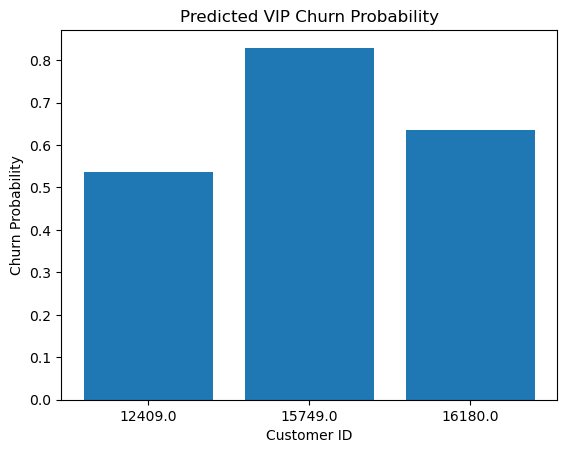

In [19]:
plt.figure()

plt.bar(range(len(df)), df["churn_probability_scaled"])

plt.xticks(range(len(df)), df["CustomerID"])

plt.xlabel("Customer ID")
plt.ylabel("Churn Probability")
plt.title("Predicted VIP Churn Probability")

plt.show()

In [20]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coef_df)

               Feature  Coefficient
0             monetary     0.288378
1            frequency     0.238377
2  days_since_purchase     0.502667


## 🧠 Key Business Insights

- Customer inactivity (recency) is the strongest predictor of churn.
- High-value customers can still churn if they become inactive.
- 3 VIP customers were identified as at-risk.
- Customer 15749 is the highest priority for retention.
- A simple logistic regression model successfully predicts churn probability.

## 📌 Recommendation

Focus retention efforts on high-value customers with long inactivity periods using targeted campaigns (discounts, emails, loyalty incentives).